In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages

class ResearchState(TypedDict):
    # Annotated[list, add_messages] 是一个合并注解：每次往 messages写数据时，不会覆盖而是追加（类似 +=）
    messages: Annotated[list, add_messages]
    query: str
    search_results: list[dict]
    report: str

In [3]:
from langchain_tavily import TavilySearch

def search_web(state: ResearchState) -> ResearchState:
    tool = TavilySearch(max_results=5)
    raw_results = tool.invoke(state["query"])
    if isinstance(raw_results, dict):
        results = raw_results.get("results", [])
    elif isinstance(raw_results, list):
        results = raw_results
    else:
        results = []
    return {"search_results": results}

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
import os

model = os.getenv("MODEL_NAME")

if model is None:
    raise ValueError("MODEL_NAME is not set")

llm = ChatOpenAI(model=model, temperature=0, extra_body={"enable_thinking": False})

def synthesize_report(state: ResearchState) -> ResearchState:
    results_text = "\n\n".join(
        f"Source: {r.get('url', 'N/A')}\nTitle: {r.get('title', 'N/A')}\nContent: {r.get('content', '')[:500]}"
        for r in state["search_results"]
    )

    messages = [
        SystemMessage(content="You are a research analyst. Synthesize the search results into a clear, structured report with: Summary, Key Findings (bullet points), and Sources."),
        HumanMessage(content=f"Research query: {state['query']}\n\nSearch results:\n{results_text}"),
    ]

    response = llm.invoke(messages)
    return {"report": response.content, "messages": [response]}

In [5]:
from langgraph.graph import StateGraph, START, END

def build_graph():
    graph = StateGraph(ResearchState)
    graph.add_node("search", search_web)
    graph.add_node("synthesize", synthesize_report)
    # graph.set_entry_point("search")
    graph.add_edge(START, "search")
    graph.add_edge("search", "synthesize")
    graph.add_edge("synthesize", END)
    return graph.compile()

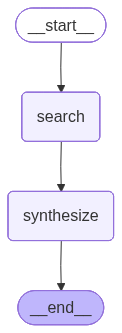

# QDII基金今日行情研究报告

## 1. 摘要 (Summary)
根据最新市场数据，QDII（合格境内机构投资者）基金整体表现呈现分化态势。部分全球精选及科技类QDII基金今日录得上涨，其中广发全球精选股票（QDII）A涨幅接近1%；而部分聚焦特定行业或区域的基金则出现不同程度的下跌，跌幅在1.8%至2.5%之间。此外，部分头部QDII基金近期发布了暂停申购的公告，投资者需注意流动性限制。以下报告基于英为财情、东方财富、证券之星等主流金融平台提供的实时及近期净值数据进行汇总。

## 2. 关键发现 (Key Findings)

### **表现较好的基金（上涨）**
*   **广发全球精选股票（QDII）A (代码: 270023)**：
    *   **最新净值**：6.924元
    *   **当日涨跌**：+0.055元 (+0.80%)
    *   **分析**：该基金今日表现稳健，小幅上涨，显示其持仓的全球资产组合在当前市场环境下具有一定的抗跌性或增长动力。
*   **广发美国精选股票(QDII) (代码: 118001)**：
    *   **最新净值**：1.6620元
    *   **累计净值**：1.6620元
    *   **涨跌幅**：+2.28%
    *   **注意**：数据显示该基金近期有暂停申购的状态（截至2026/7/3公告），投资者需关注后续开放情况。
*   **其他上涨品种**：
    *   某全球A类份额（疑似广发相关）：涨幅 +3.77%
    *   某全球A类份额（美元现汇）：涨幅 +3.10%
    *   易方达全球精选（推测）：涨幅 +2.78%

### **表现较差的基金（下跌）**
*   **医药与健康类QDII承压**：
    *   **某医药精选(QDII)C (代码: 025655)**：净值0.9963，跌幅 **-1.82%**
    *   **某日本精选股票(QDII)C (代码: 019449)**：净值2.1996，跌幅 **-1.84%**
    *   **某医疗大健康(QDII)A (代码: 025070)**：净值0.8881，跌幅 **-2.54%**
*   **长期业绩波动较大的基金（来自东方财富数据）**：
   

In [7]:
from IPython.display import Image, display
from langgraph.graph.message import BaseMessage

agent = build_graph()

display(Image(agent.get_graph().draw_mermaid_png()))

result = agent.stream(input={"query": 'QDII基金今日行情', "messages": [], "search_results": [], "report": ""}, stream_mode="messages")

for chunk in result:
    msg, metadata = chunk
    print(getattr(msg, 'content'), end='', flush=True)  # 打印的是 LLM 生成的文本内容
